In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

### Ejercicio 2 - Péndulo Forzado.

El péndulo no lineal puede forzarse introduciendo por ejemplo ejerciendo una fuerza oscilatoria horizontal a la masa. En ese caso, la ecuación del movimiento viene dada por:

$$\frac{\text{d}^2\theta}{\text{d}t^2}=-\frac{g}{l}\sin{\theta}+C\cos\theta\sin\Omega t,$$

siendo $C$ y $\Omega$ constantes. 


Escribir un programa que resuelva la ecuación del movimiento de un péndulo forzado con $l=10$ cm, $C= 2\, \text{s}^{-2}$ y $\Omega=5\,\text{s}^{-1}$ y que represente su posición en el intervalo $t\in[0,100]$ s para las condiciones iniciales $\theta =\text{d}\theta/\text{d}t=0$. 

---

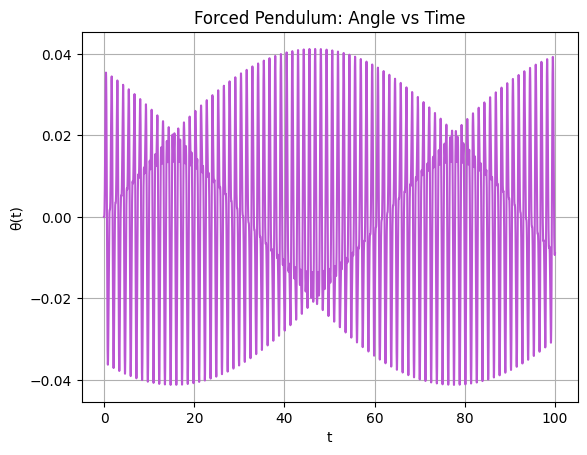

In [2]:
def rk4_system(F, a, b, N, x0, y0, plot=False):
    h = (b - a) / N
    tp = np.linspace(a, b, N)
    xp = []
    yp = []
    r = np.array([x0, y0], float)

    for t in tp:
        xp.append(r[0])
        yp.append(r[1])
        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    t = np.array(tp, float)
    x = np.array(xp, float)
    y = np.array(yp, float)

    if plot:
        plt.plot(t, x, color = mc)
        plt.plot(t, y, color = 'gray')
        plt.title("Solution")
        plt.grid()
        plt.legend(["x(t)", "y(t)"])
        plt.xlabel("t")
        plt.ylabel("r(t)")
        plt.show()

    return t, x, y

def penduloforzado(r, t):
    g = 9.8
    l = 0.1
    C = 2
    omega = 5
    x = r[0]
    y = r[1]
    fx = y
    fy = -g*np.sin(x)/l + C*np.cos(x)*np.sin(omega*t)
    return np.array([fx, fy], float)

a, b, N = 0, 100, 10000
x0, y0 = 0, 0

t, x, y = rk4_system(penduloforzado, a, b, N, x0, y0)
plt.plot(t, x, color=mc)
plt.xlabel("t")
plt.ylabel("θ(t)")
plt.title("Forced Pendulum: Angle vs Time")
plt.grid()
plt.show()